In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.Size([100, 1, 28, 28]) torch.Size([100])
epoch: 1 / 2, step: 100 / 600, loss: 1.0914
epoch: 1 / 2, step: 200 / 600, loss: 0.4793
epoch: 1 / 2, step: 300 / 600, loss: 0.5230
epoch: 1 / 2, step: 400 / 600, loss: 0.1628
epoch: 1 / 2, step: 500 / 600, loss: 0.1832
epoch: 1 / 2, step: 600 / 600, loss: 0.0474
epoch: 2 / 2, step: 100 / 600, loss: 0.1389
epoch: 2 / 2, step: 200 / 600, loss: 0.1062
epoch: 2 / 2, step: 300 / 600, loss: 0.2361
epoch: 2 / 2, step: 400 / 600, loss: 0.1316
epoch: 2 / 2, step: 500 / 600, loss: 0.0830
epoch: 2 / 2, step: 600 / 600, loss: 0.0468
accuracy = 97.38


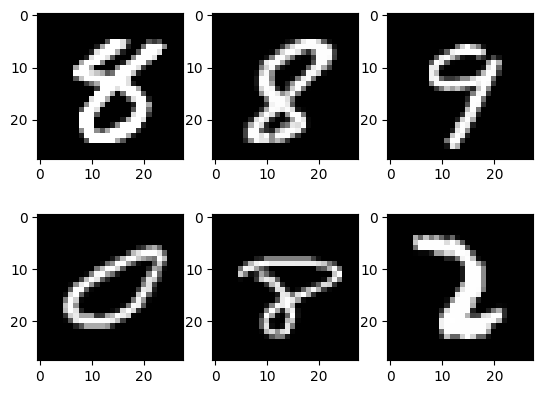

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Menentukan device komputasi:
# - Gunakan GPU jika tersedia
# - Jika tidak, gunakan CPU

# ===============================
# HYPERPARAMETER MODEL
# ===============================
hidden_size = 128
# Jumlah neuron pada hidden state RNN/LSTM

num_classes = 10
# Jumlah kelas output (digit 0–9)

num_epochs = 2
# Jumlah epoch training

batch_size = 100
# Jumlah data dalam satu batch

learning_rate = 0.001
# Learning rate optimizer

# ===============================
# REPRESENTASI DATA SEBAGAI SEQUENCE
# ===============================
input_size = 28
# Setiap timestep memiliki 28 fitur (1 baris pixel gambar)

sequence_length = 28
# Panjang sequence = 28 baris pixel (gambar 28x28)

num_layers = 2
# Jumlah layer LSTM yang ditumpuk (stacked LSTM)

# ===============================
# LOAD DATASET MNIST
# ===============================
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
# Dataset training MNIST

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transforms.ToTensor()
)
# Dataset testing MNIST

# ===============================
# DATALOADER
# ===============================
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
# DataLoader training (shuffle agar data acak setiap epoch)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)
# DataLoader testing (tidak perlu shuffle)

# ===============================
# CEK BENTUK DATA
# ===============================
example = iter(train_loader)
samples, labels = next(example)

print(samples.shape, labels.shape)
# samples: [batch_size, 1, 28, 28]
# labels : [batch_size]

# ===============================
# VISUALISASI SAMPLE DATA
# ===============================
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(samples[i][0], cmap='gray')
# Menampilkan 6 contoh gambar MNIST

# ===============================
# DEFINISI MODEL RNN (LSTM)
# ===============================
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN, self).__init__()
        # input_size  : jumlah fitur per timestep
        # hidden_size : ukuran hidden state
        # num_layers  : jumlah layer LSTM
        # num_classes : jumlah kelas output

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        # batch_first=True → input berbentuk [batch, seq_len, input_size]
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Fully Connected layer untuk klasifikasi
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Inisialisasi hidden state awal (h0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Inisialisasi cell state awal (c0) khusus LSTM
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Forward pass LSTM
        # out: [batch_size, sequence_length, hidden_size]
        out, _ = self.lstm(x, (h0, c0))

        # Ambil output timestep terakhir
        # out[:, -1, :] → representasi akhir sequence
        out = out[:, -1, :]

        # Mapping ke jumlah kelas
        out = self.fc(out)

        return out
        # Output berupa logits (belum softmax)

# ===============================
# INISIALISASI MODEL
# ===============================
model = RNN(input_size, hidden_size, num_layers, num_classes).to(device)

# ===============================
# LOSS & OPTIMIZER
# ===============================
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss = Softmax + Negative Log Likelihood
# Cocok untuk klasifikasi multi-class

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# Optimizer Adam

# ===============================
# TRAINING LOOP
# ===============================
n_total_steps = len(train_loader)

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        # Reshape gambar menjadi sequence:
        # [batch, 1, 28, 28] → [batch, 28, 28]
        images = images.reshape(-1, sequence_length, input_size).to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Logging
        if (i+1) % 100 == 0:
            print(f'epoch: {epoch+1} / {num_epochs}, step: {i+1} / {n_total_steps}, loss: {loss.item():.4f}')

# ===============================
# EVALUATION (TESTING)
# ===============================
with torch.no_grad():
    n_correct = 0
    n_samples = 0

    for images, labels in test_loader:
        images = images.reshape(-1, sequence_length, input_size).to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Ambil kelas dengan skor terbesar
        _, predicted = torch.max(outputs.data, 1)

        n_samples += labels.shape[0]
        n_correct += (predicted == labels).sum().item()

    acc = 100.0 * n_correct / n_samples
    print(f'accuracy = {acc}')

In [ ]:
"""
Kode ini membangun dan melatih model LSTM (RNN) untuk klasifikasi
gambar MNIST dengan pendekatan SEQUENCE MODELING.

Gambar 28x28 diperlakukan sebagai:
- 28 timestep (baris pixel)
- Setiap timestep memiliki 28 fitur

Alur utama:
1. Load dataset MNIST
2. Ubah gambar menjadi sequence
3. Proses sequence menggunakan LSTM
4. Ambil hidden state terakhir
5. Gunakan Fully Connected layer untuk klasifikasi
6. Training menggunakan CrossEntropyLoss
7. Evaluasi akurasi pada data test

Perbedaan utama dengan MLP/CNN:
- RNN memproses data secara berurutan (temporal)
- Hidden state menyimpan informasi dari timestep sebelumnya
"""

'\nKode ini membangun dan melatih model LSTM (RNN) untuk klasifikasi\ngambar MNIST dengan pendekatan SEQUENCE MODELING.\n\nGambar 28x28 diperlakukan sebagai:\n- 28 timestep (baris pixel)\n- Setiap timestep memiliki 28 fitur\n\nAlur utama:\n1. Load dataset MNIST\n2. Ubah gambar menjadi sequence\n3. Proses sequence menggunakan LSTM\n4. Ambil hidden state terakhir\n5. Gunakan Fully Connected layer untuk klasifikasi\n6. Training menggunakan CrossEntropyLoss\n7. Evaluasi akurasi pada data test\n\nPerbedaan utama dengan MLP/CNN:\n- RNN memproses data secara berurutan (temporal)\n- Hidden state menyimpan informasi dari timestep sebelumnya\n'

In [ ]:
# ============================================================
# CATATAN PENTING – RNN / LSTM (BERDASARKAN DISKUSI)
# ============================================================

# 1. PERBEDAAN hidden_size vs num_layers
# ------------------------------------------------------------
# hidden_size:
# - Menentukan JUMLAH NEURON pada setiap hidden state RNN/LSTM.
# - Semakin besar hidden_size → representasi fitur makin kaya.
# - Contoh: hidden_size = 128 → tiap timestep menghasilkan vektor 128.

# num_layers:
# - Menentukan JUMLAH LAYER RNN/LSTM yang ditumpuk (stacked).
# - num_layers = 1 → hanya 1 layer RNN.
# - num_layers = 2 → output layer pertama menjadi input layer kedua.
# - Tidak mengubah panjang sequence, hanya memperdalam model.


# 2. APA FUNGSI FULLY CONNECTED (fc) DI AKHIR RNN?
# ------------------------------------------------------------
# Fully Connected layer (nn.Linear):
# - Mengubah hidden state terakhir menjadi skor kelas (logits).
# - Menggabungkan seluruh informasi temporal yang telah dipelajari RNN.
# - Operasi matematis: y = W·h + b

# Urutan umumnya:
# hidden state terakhir → Linear → logits → CrossEntropyLoss
# Softmax TIDAK ditulis eksplisit karena sudah ada di CrossEntropyLoss.


# 3. APAKAH FULLY CONNECTED WAJIB?
# ------------------------------------------------------------
# Tidak selalu wajib, tetapi:
# - Hampir selalu digunakan untuk TASK KLASIFIKASI.
# - CNN, MLP, RNN biasanya berakhir dengan FC layer.
# - Tanpa FC, model sulit memetakan fitur → kelas.

# Alternatif:
# - Global Average Pooling (CNN modern)
# - 1x1 Convolution
# - Attention-based head (Transformer)


# 4. APA ITU sequence_length DI KODE INI?
# ------------------------------------------------------------
# sequence_length = 28
# Artinya:
# - Setiap gambar MNIST (28x28) dianggap sebagai 28 timestep.
# - Setiap timestep = 1 baris pixel (panjang 28).

# Jadi representasi data:
# [batch, 1, 28, 28] → [batch, sequence_length=28, input_size=28]

# RNN membaca gambar BARIS DEMI BARIS, bukan sekaligus.


# 5. KENAPA RNN BISA DIGUNAKAN UNTUK GAMBAR?
# ------------------------------------------------------------
# RNN SEBENARNYA untuk data berurutan (teks, waktu, sinyal).
# Pada MNIST:
# - Gambar "dipaksa" menjadi sequence
# - Tujuannya edukatif: memahami RNN, bukan performa terbaik

# CNN lebih cocok untuk gambar karena:
# - Menangkap pola spasial (tepi, tekstur)
# - Lebih efisien & akurat


# 6. PERBEDAAN RNN vs MLP (SECARA ARSITEKTUR)
# ------------------------------------------------------------
# MLP:
# - Tidak punya memori
# - Semua input diproses sekaligus
# - Tidak peduli urutan data

# RNN:
# - Memiliki hidden state (memori)
# - Memproses input secara berurutan
# - Output tergantung input saat ini + masa lalu

# Walaupun sama-sama punya hidden layer,
# RNN ≠ MLP karena adanya FEEDBACK CONNECTION.


# 7. KENAPA RNN/LSTM PUNYA h0 DAN c0?
# ------------------------------------------------------------
# h0 (hidden state):
# - Menyimpan informasi jangka pendek

# c0 (cell state, khusus LSTM):
# - Menyimpan informasi jangka panjang
# - Mengatasi vanishing gradient

# Biasanya diinisialisasi dengan nol.


# 8. URUTAN PROSES PADA MODEL INI
# ------------------------------------------------------------
# 1) Gambar MNIST diubah menjadi sequence
# 2) Sequence diproses oleh LSTM timestep demi timestep
# 3) Hidden state terakhir diambil
# 4) Fully Connected mengubahnya jadi logits
# 5) CrossEntropyLoss menghitung loss
# 6) Backpropagation + Optimizer update bobot


# 9. KESIMPULAN BESAR
# ------------------------------------------------------------
# - hidden_size → lebar representasi
# - num_layers → kedalaman RNN
# - FC layer → pemetaan fitur → kelas
# - sequence_length → panjang urutan data
# - RNN unggul untuk data berurutan, bukan gambar murni
# ============================================================
